In [1]:
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import KDTree
import xarray as xr
from MHW_funcs import get_oisst_flag, get_oisst_flag_spatialONLY
from MHW_funcs import map_study_region
import matplotlib.pyplot as plt
import matplotlib.colors as mpcolors
from cmocean import cm as cmo
from cartopy import crs as ccrs
from cartopy import feature as cfeature 
import matplotlib.ticker as ticker
import boto3
import gsw
import datetime
import s3fs
import cmocean
import subprocess

BOLD = "\033[1m"
RESET = "\033[0m"
RED = "\033[31m"
LINE = "\033[4m"

## 1. Grab data

Data is from [CrocoLake](https://crocolakedocs.readthedocs.io/en/latest/).

Method for ingesting the data based on [script](https://github.com/go-bgc/Marine-Heat-Waves/blob/main/notebooks/Argo_subset.ipynb) by Roo Nicholson.

### 1.1. Select MHW

In [2]:
# Path to Crocolake
parquet_dir = '/home/jovyan/shared/go-bgc-2026/data/CrocoLake/BGC_CROCOLAKE/'

# path to heatwave csv
csv_path = '/home/jovyan/Marine-Heat-Waves/MHW_list.csv'

# open heatwave database and format
dfhw = pd.read_csv(csv_path)
dfhw.set_index('name',inplace=True)
date_cols = ['date_start','date_end']
dfhw[date_cols] = dfhw[date_cols].apply(pd.to_datetime)

# print heatwave options
print(f"{BOLD}Select from the following:{RESET} \n" + ", ".join(f"{n}: {idx}" for n, idx in enumerate(dfhw.index, start=0)))

# Choose a HW
hw = "SWPac2023"

# Boundaries
lat0 = dfhw.loc[hw,'lat0'] 
lat1 = dfhw.loc[hw,'lat1'] 
lon0 = dfhw.loc[hw,'lon0'] 
lon1 = dfhw.loc[hw,'lon1'] 
z0 = 0
z1 = 500
date0 = dfhw.loc[hw,'date_start']
date1 = dfhw.loc[hw,'date_end']

Select from the following: 
0: Med2003, 1: Beng2001, 2: WA2011, 3: NWA2012, 4: WSA2014, 5: ECS2016, 6: AL2016, 7: NA2016, 8: NEP2015, 9: Tas2017, 10: Peru2017, 11: NA 2023, 12: SWPac2023


### 1.2. Get the data from the chosen MHW.

This method does deal with domains that cross 180<sup>o</sup> longitude.

In [3]:
# Setting up parquet schema
parquet_dir = '~/shared/go-bgc-2026/data/CrocoLake/BGC_ARGO/'
BGC_schema = pq.read_schema(parquet_dir+"_common_metadata")

# If lon crosses 180deg
if lon0 > lon1:
    # First half of meridional domain
    filters1 = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",lon0), ("LONGITUDE","<=",180),
                ("JULD",">",date0), ("JULD","<",date1),
                ("PRES","<",z1), #("PRES",">=",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df1 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters1)
    df1 = df1.read().to_pandas()
    df1 = pd.read_parquet(parquet_dir, schema=BGC_schema, filters=filters1)

    # Second half of meridional domain
    filters2 = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",-180), ("LONGITUDE","<=",lon1),
                ("JULD",">",date0), ("JULD","<",date1),
                ("PRES","<",z1), #("PRES",">=",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df2 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters2)
    df2 = df2.read().to_pandas()

    # Combine domains
    df = pd.concat([df1, df2], ignore_index=True)

# If lon does NOT cross 180deg (normal case)
else:
    filters = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
                ("JULD",">",date0), ("JULD","<",date1),
                ("PRES","<",z1), #("PRES",">",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters)
    df = df.read().to_pandas()



In [4]:
N = 0
# list platform numbers and cycle numbers
for ID in df['PLATFORM_NUMBER'].unique():
    print(f"{BOLD}Float Number = {ID}{RESET}")
    float_df = df[df['PLATFORM_NUMBER'] == ID]
    float_df.reset_index(drop = True)
 
    print(f"--{LINE}Cycle Numbers = {np.array(float_df['CYCLE_NUMBER'].unique()).tolist()}{RESET}")
    N = N + len(float_df['CYCLE_NUMBER'].unique())

Float Number = 5905441
--Cycle Numbers = [144]
Float Number = 5905442
--Cycle Numbers = [141, 142]
Float Number = 5905501
--Cycle Numbers = [91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105]
Float Number = 5905505
--Cycle Numbers = [91, 92, 93, 99]
Float Number = 5905555
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Float Number = 5905556


--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Float Number = 5905557
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Float Number = 5906623
--Cycle Numbers = [266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295]
Float Number = 5906624
--Cycle Numbers = [150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 163, 161, 162, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186]
Float Number = 5906635
--Cycle Numbers = [72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112]
Float Number = 5905218


--Cycle Numbers = [180]
Float Number = 5906443
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
Float Number = 5906509
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8]
Float Number = 5906581
--Cycle Numbers = [1]
Float Number = 5906307
--Cycle Numbers = [90, 91, 92, 93, 94, 95, 101]
Float Number = 5906311
--Cycle Numbers = [68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108]
Float Number = 5906319
--Cycle Numbers = [68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]
Float Number = 5906444
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Float Number = 2903455


--Cycle Numbers = [1, 2, 3, 4, 5, 6]
Float Number = 2903456
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Float Number = 5906542
--Cycle Numbers = [1, 2, 3]
Float Number = 5906545
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Float Number = 5906546
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Float Number = 2903457
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
Float Number = 5906550
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
Float Number = 5906551


--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
Float Number = 5906552
--Cycle Numbers = [1, 2, 3, 4, 5]
Float Number = 5906553
--Cycle Numbers = [1, 2, 3]
Float Number = 5906554
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Float Number = 5906555
--Cycle Numbers = [1]
Float Number = 5906567
--Cycle Numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]


### 1.3. Select only the data you want

In [5]:
want_Oxygen = True
want_BBP = True
want_Turbidity = True
want_CP = True
want_Chla = True
want_CDOM = True
want_Nitrate = True
want_Bisulfide = True
want_pH = True
want_DownwellingIR = True
want_UpwellingIR = True
want_DownwellingPAR = True

In [6]:
base_info = ['PLATFORM_NUMBER', 'N_PROF', 'N_LEVELS', 'CYCLE_NUMBER', 'LATITUDE', 'LONGITUDE', 'JULD', 
             'PRES', 'TEMP', 'PSAL']
oxygen_info = ['DOXY_ADJUSTED', 'DOXY_ADJUSTED_QC', 'DOXY_ADJUSTED_ERROR']
bbp_info = ['BBP_ADJUSTED', 'BBP_ADJUSTED_QC', 'BBP_ADJUSTED_ERROR']
turbidity_info = ['TURBIDITY_ADJUSTED', 'TURBIDITY_ADJUSTED_QC', 'TURBIDITY_ADJUSTED_ERROR']
cp_info = ['CP_ADJUSTED', 'CP_ADJUSTED_QC', 'CP_ADJUSTED_ERROR']
chla_info = ['CHLA_ADJUSTED', 'CHLA_ADJUSTED_QC', 'CHLA_ADJUSTED_ERROR',
            'CHLA_FLUORESCENCE_ADJUSTED', 'CHLA_FLUORESCENCE_ADJUSTED_QC', 'CHLA_FLUORESCENCE_ADJUSTED_ERROR',
            ]
cdom_info = ['CDOM_ADJUSTED', 'CDOM_ADJUSTED_QC', 'CDOM_ADJUSTED_ERROR']
nitrate_info = ['NITRATE_ADJUSTED', 'NITRATE_ADJUSTED_QC', 'NITRATE_ADJUSTED_ERROR']
bisulfide_info = ['BISULFIDE_ADJUSTED', 'BISULFIDE_ADJUSTED_QC', 'BISULFIDE_ADJUSTED_ERROR']
ph_info = ['PH_IN_SITU_TOTAL_ADJUSTED', 'PH_IN_SITU_TOTAL_ADJUSTED_QC', 'PH_IN_SITU_TOTAL_ADJUSTED_ERROR']
downirrad_info = ['DOWN_IRRADIANCE_ADJUSTED', 'DOWN_IRRADIANCE_ADJUSTED_QC', 'DOWN_IRRADIANCE_ADJUSTED_ERROR']
upirrad_info = ['UP_IRRADIANCE_ADJUSTED', 'UP_IRRADIANCE_ADJUSTED_QC', 'UP_IRRADIANCE_ADJUSTED_ERROR']
downpar_info = ['DOWNWELLING_PAR_ADJUSTED', 'DOWNWELLING_PAR_ADJUSTED_QC', 'DOWNWELLING_PAR_ADJUSTED_ERROR']

In [7]:
params = base_info

if want_Oxygen:
    params = params + oxygen_info
if want_BBP:
    params = params + bbp_info
if want_Turbidity:
    params = params + turbidity_info
if want_CP:
    params = params + cp_info
if want_Chla:
    params = params + chla_info
if want_CDOM:
    params = params + cdom_info
if want_Nitrate:
    params = params + nitrate_info
if want_Bisulfide:
    params = params + bisulfide_info
if want_pH:
    params = params + ph_info
if want_DownwellingIR:
    params = params + downirrad_info
if want_UpwellingIR:
    params = params + upirrad_info
if want_DownwellingPAR:
    params = params + downpar_info

print(f"You have selected the following parameters before QC: {params}")

df = df.loc[:,params]

You have selected the following parameters before QC: ['PLATFORM_NUMBER', 'N_PROF', 'N_LEVELS', 'CYCLE_NUMBER', 'LATITUDE', 'LONGITUDE', 'JULD', 'PRES', 'TEMP', 'PSAL', 'DOXY_ADJUSTED', 'DOXY_ADJUSTED_QC', 'DOXY_ADJUSTED_ERROR', 'BBP_ADJUSTED', 'BBP_ADJUSTED_QC', 'BBP_ADJUSTED_ERROR', 'TURBIDITY_ADJUSTED', 'TURBIDITY_ADJUSTED_QC', 'TURBIDITY_ADJUSTED_ERROR', 'CP_ADJUSTED', 'CP_ADJUSTED_QC', 'CP_ADJUSTED_ERROR', 'CHLA_ADJUSTED', 'CHLA_ADJUSTED_QC', 'CHLA_ADJUSTED_ERROR', 'CHLA_FLUORESCENCE_ADJUSTED', 'CHLA_FLUORESCENCE_ADJUSTED_QC', 'CHLA_FLUORESCENCE_ADJUSTED_ERROR', 'CDOM_ADJUSTED', 'CDOM_ADJUSTED_QC', 'CDOM_ADJUSTED_ERROR', 'NITRATE_ADJUSTED', 'NITRATE_ADJUSTED_QC', 'NITRATE_ADJUSTED_ERROR', 'BISULFIDE_ADJUSTED', 'BISULFIDE_ADJUSTED_QC', 'BISULFIDE_ADJUSTED_ERROR', 'PH_IN_SITU_TOTAL_ADJUSTED', 'PH_IN_SITU_TOTAL_ADJUSTED_QC', 'PH_IN_SITU_TOTAL_ADJUSTED_ERROR', 'DOWN_IRRADIANCE_ADJUSTED', 'DOWN_IRRADIANCE_ADJUSTED_QC', 'DOWN_IRRADIANCE_ADJUSTED_ERROR', 'UP_IRRADIANCE_ADJUSTED', 'UP_IRR

### 1.4. Filter out bad data

#### [QC Flags](https://argo.ucsd.edu/data/how-to-use-argo-files/)
| QC flag | Meaning                                   | Real time comment                                                                                                                                                                                                                                                       | Delayed mode comment                                                                         |
|---------|-------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------|
| 0       | No QC performed                           | No QC performed                                                                                                                                                                                                                                                         | No QC performed                                                                              |
| 1       | Good data                                 | All real time QC tests passed                                                                                                                                                                                                                                           | The adjusted value is statistically consistent and a statistical error estimate is supplied. |
| 2       | Probably good data                        |                                                                                                                                                                                                                                                                         | Probably good                                                                                |
| 3       | Bad data that are potentially correctable | Test 15 or Test 16 or Test 17 failed and all other real-time QC  tests passed. These data are not to be used without scientific  correction. A flag ‘3’ may be assigned by an operator during additional  visual QC for bad data that may be corrected in delayed mode. | An adjustment has been applied, but the value may still be bad.                              |
| 4       | Bad data                                  | Data have failed one or more of the real-time QC tests, excluding  Test 16. A flag ‘4’ may be assigned by an operator during additional  visual QC for bad data that are not correctable.                                                                               | Bad data.  Not adjustable.                                                                   |
| 5       | Value changed                             | Value changed                                                                                                                                                                                                                                                           | Value changed                                                                                |
| 6       | Not currently used                        | Not currently used                                                                                                                                                                                                                                                      | Not currently used                                                                           |
| 7       | Not currently used                        | Not currently used                                                                                                                                                                                                                                                      | Not currently used                                                                           |
| 8       | Estimated                                 | Estimated value (interpolated, extrapolated or other estimation).                                                                                                                                                                                                       | Estimated value (interpolated, extrapolated or other estimation).                            |
| 9       | Missing value                             | Missing value                                                                                                                                                                                                                                                           | Missing value                                                                                |

In [8]:
qc_strings = [s for s in params if s.endswith("QC")]
bad_vals = [0,3,4,6,7,9]

In [9]:
for s in qc_strings:
    var = s.removesuffix("_QC")

    df.loc[df[s].isin(bad_vals), var] = np.nan

### 1.5. Some info on the data

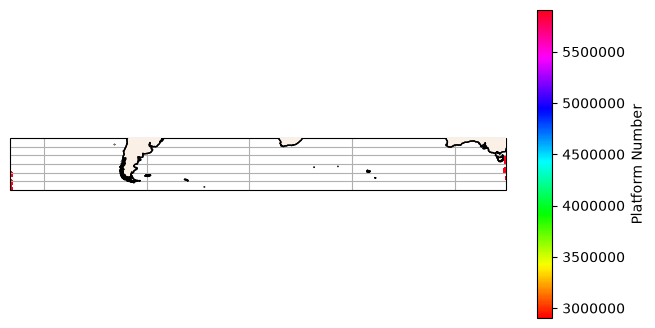

In [10]:
ax = map_study_region(ax_lims = [lon0, lon1, lat0, lat1+10]) #, PROJ = ccrs.SouthPolarStereo())
im = ax.scatter(df['LONGITUDE'], df['LATITUDE'], 
                s = 10, c = df['PLATFORM_NUMBER'], cmap = 'hsv',
                transform=ccrs.PlateCarree())
cbar = plt.colorbar(im, ax = ax)
cbar.ax.ticklabel_format(style='plain', axis='y')
cbar.set_label('Platform Number')

## 2. More data processing!
### 2.1. Adding month and year

In [11]:
df = df.assign(MONTH = [pd.Timestamp(ti).month for ti in df.loc[:,'JULD'].values])
df = df.assign(YEAR = [pd.Timestamp(ti).year for ti in df.loc[:,'JULD'].values])

### 2.2. Masking data for the MHW

[Function to flag data](https://github.com/go-bgc/Marine-Heat-Waves/blob/main/contributors/ellen/ellen_fxns.py) written by Ellen Park, edited by Abby Baskind.

Masks of the North Atlantic 2023 and Southwest Pacific 2023 heatwave created by Cassia Cai from [OISST data](https://www.ncei.noaa.gov/products/optimum-interpolation-sst).

In [12]:
if hw == "NA 2023":
    mask_link = 's3://uw-escience-scratch-prod/oisst/mhw_mask_north_atlantic_final.zarr'
elif hw == "SWPac2023":
    mask_link = 's3://uw-escience-scratch-prod/oisst/mhw_mask_swp_final.zarr'

In [13]:
df_mhw = get_oisst_flag(df, oisst_path = mask_link)

Openining : s3://uw-escience-scratch-prod/oisst/mhw_mask_swp_final.zarr


0  out of 308


100  out of 308


200  out of 308


300  out of 308


In [14]:
df_mhw = df_mhw[df_mhw['mhw_mask'] == 1]

## 3. Make some preliminary plots
### 3.1. Temperature

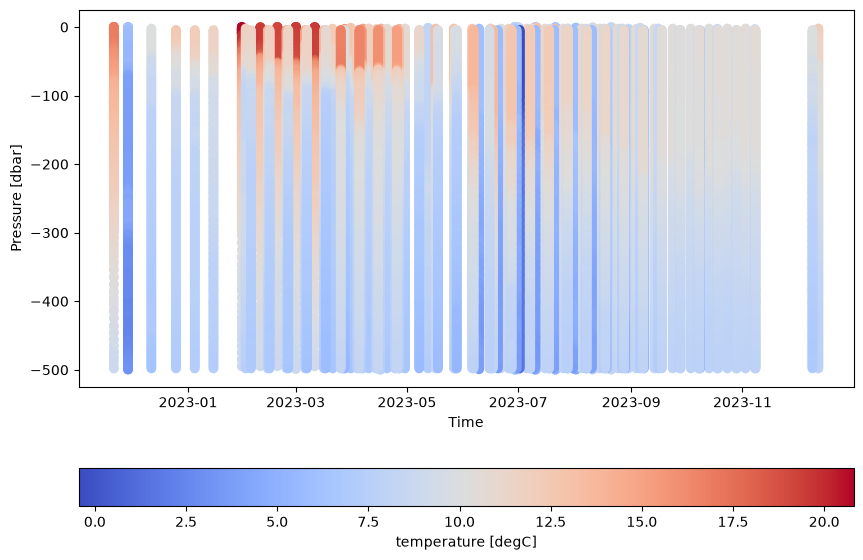

In [15]:
fig, ax = plt.subplots(figsize = [10,7])

x = df_mhw['JULD']
y = -df_mhw['PRES']
z = df_mhw['TEMP']

im = ax.scatter(x, y, c = z, cmap = 'coolwarm')
ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")
cbar = plt.colorbar(im, ax = ax, orientation = 'horizontal')
cbar.set_label("temperature [degC]")

### 3.2. Oxygen

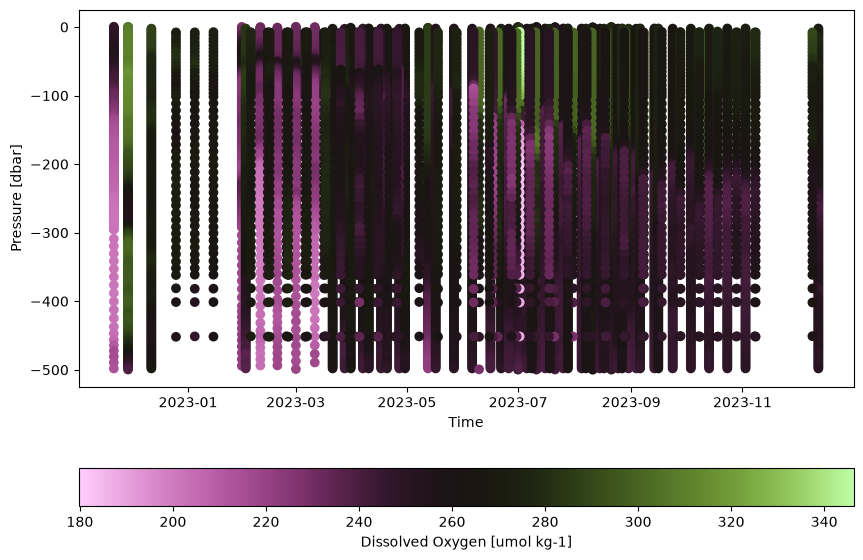

In [16]:
fig, ax = plt.subplots(figsize = [10,7])

x = df_mhw['JULD']
y = -df_mhw['PRES']
z = df_mhw['DOXY_ADJUSTED']

im = ax.scatter(x, y, c = z, cmap = 'vanimo')
ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")
cbar = plt.colorbar(im, ax = ax, orientation = 'horizontal')
cbar.set_label("Dissolved Oxygen [umol kg-1]")

### 3.3. pH

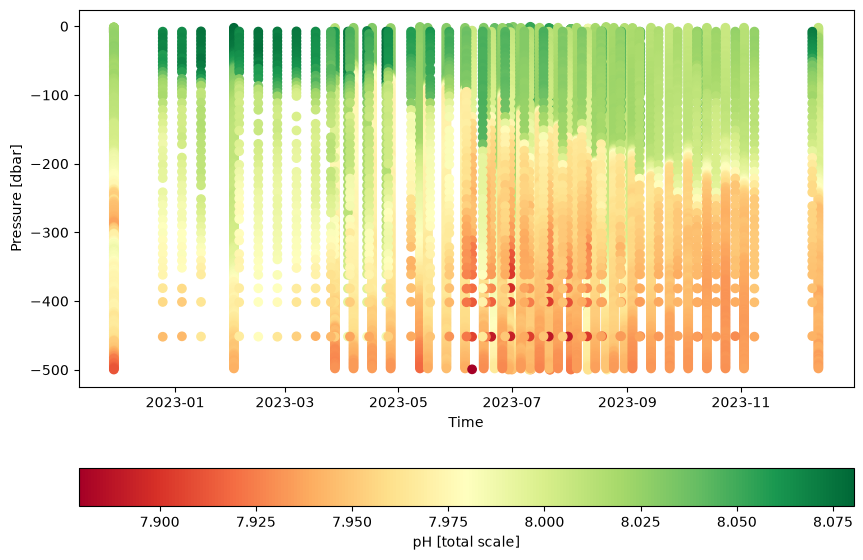

In [17]:
fig, ax = plt.subplots(figsize = [10,7])

x = df_mhw['JULD']
y = -df_mhw['PRES']
z = df_mhw['PH_IN_SITU_TOTAL_ADJUSTED']

im = ax.scatter(x, y, c = z, cmap = 'RdYlGn')
ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")
cbar = plt.colorbar(im, ax = ax, orientation = 'horizontal')
cbar.set_label("pH [total scale]")

## 4. List out all the platforms and clcyes

In [18]:
N = 0
# list platform numbers and cycle numbers
for ID in df_mhw['PLATFORM_NUMBER'].unique():
    print(f"{BOLD}Float Number = {ID}{RESET}")
    float_df = df_mhw[df_mhw['PLATFORM_NUMBER'] == ID]
    float_df.reset_index(drop = True)

    KEYS = []
    for key in float_df.keys():
        if key.endswith("ADJUSTED"):
            if float_df[key].isna().all():
                KEYS.append(key)

    print(f"{RED}Included BGC variables: {KEYS}{RESET}")
 
    print(f"--{LINE}Cycle Numbers = {np.array(float_df['CYCLE_NUMBER'].unique()).tolist()}{RESET}")
    N = N + len(float_df['CYCLE_NUMBER'].unique())
        
        
        

Float Number = 5906623
Included BGC variables: ['BBP_ADJUSTED', 'TURBIDITY_ADJUSTED', 'CP_ADJUSTED', 'CHLA_FLUORESCENCE_ADJUSTED', 'CDOM_ADJUSTED', 'BISULFIDE_ADJUSTED', 'DOWN_IRRADIANCE_ADJUSTED', 'UP_IRRADIANCE_ADJUSTED', 'DOWNWELLING_PAR_ADJUSTED']
--Cycle Numbers = [274, 275, 276, 278, 279]
Float Number = 5906624
Included BGC variables: ['BBP_ADJUSTED', 'TURBIDITY_ADJUSTED', 'CP_ADJUSTED', 'CHLA_FLUORESCENCE_ADJUSTED', 'CDOM_ADJUSTED', 'BISULFIDE_ADJUSTED', 'DOWN_IRRADIANCE_ADJUSTED', 'UP_IRRADIANCE_ADJUSTED', 'DOWNWELLING_PAR_ADJUSTED']
--Cycle Numbers = [151, 170, 171, 172, 173]
Float Number = 5906635
Included BGC variables: ['BBP_ADJUSTED', 'TURBIDITY_ADJUSTED', 'CP_ADJUSTED', 'CHLA_FLUORESCENCE_ADJUSTED', 'CDOM_ADJUSTED', 'BISULFIDE_ADJUSTED', 'PH_IN_SITU_TOTAL_ADJUSTED', 'DOWN_IRRADIANCE_ADJUSTED', 'UP_IRRADIANCE_ADJUSTED', 'DOWNWELLING_PAR_ADJUSTED']
--Cycle Numbers = [72, 79, 80, 81, 82, 83]
Float Number = 5906443
Included BGC variables: ['BBP_ADJUSTED', 'TURBIDITY_ADJUSTED'

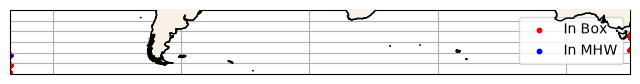

In [19]:
ax = map_study_region(ax_lims = [lon0, lon1, lat0, lat1+10]) #, PROJ = ccrs.SouthPolarStereo())
im = ax.scatter(df['LONGITUDE'], df['LATITUDE'], 
                s = 10, c = 'red',
                transform=ccrs.PlateCarree(), 
                label = "In Box")
im = ax.scatter(df_mhw['LONGITUDE'], df_mhw['LATITUDE'], 
                s = 10, c = 'blue',
                transform=ccrs.PlateCarree(),
                label = "In MHW")
ax.legend()

## 5. Find float data in MHW spatial mask but outside of time bounds

Based on the same methodology used before to identify data in the heatwave. 
* Filter Crocolake data by the spatial bounds of the MHW.
* In 2 separate steps, further filter data by what occurs before the MHW and what occurs after MHW.
* Pick the parameters you're interested in. This is the same as what you selected for the MHW.
* Filter out bad data based on same contraints as before.
* Apply a mask that is spatial only. It takes out the time variable of the MHW mask and collapses the spatial coords to a 2D grid. It selects only lat-lon coords that have a MHW during the time bounds of the MHW selected.

In [20]:
# ******************************
# BEFORE MHW
# ******************************

# If lon crosses 180deg
if lon0 > lon1:
    # First half of meridional domain
    filters1 = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",lon0), ("LONGITUDE","<=",180),
                ("JULD","<",date0), #("JULD",">",date1),
                ("PRES","<",z1), #("PRES",">=",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df1 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters1)
    df1 = df1.read().to_pandas()

    # Second half of meridional domain
    filters2 = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",-180), ("LONGITUDE","<=",lon1),
                ("JULD","<",date0), #("JULD",">",date1),
                ("PRES","<",z1), #("PRES",">=",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df2 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters2)
    df2 = df2.read().to_pandas()

    # Combine domains
    df_clim_before = pd.concat([df1, df2], ignore_index=True)

# If lon does NOT cross 180deg (normal case)
else:
    filters = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
                ("JULD","<",date0), #("JULD",">",date1),
                ("PRES","<",z1), #("PRES",">",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df_clim_before = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters)
    df_clim_before = df_clim_before.read().to_pandas()

# ******************************
# AFTER MHW
# ******************************

# If lon crosses 180deg
if lon0 > lon1:
    # First half of meridional domain
    filters1 = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",lon0), ("LONGITUDE","<=",180),
                ("JULD",">",date1),
                ("PRES","<",z1), #("PRES",">=",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df1 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters1)
    df1 = df1.read().to_pandas()

    # Second half of meridional domain
    filters2 = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",-180), ("LONGITUDE","<=",lon1),
                ("JULD",">",date1),
                ("PRES","<",z1), #("PRES",">=",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df2 = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters2)
    df2 = df2.read().to_pandas()

    # Combine domains
    df_clim_after = pd.concat([df1, df2], ignore_index=True)

# If lon does NOT cross 180deg (normal case)
else:
    filters = [
                ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
                ("JULD",">",date1),
                ("PRES","<",z1), #("PRES",">",z0),
                # ("DB_NAME","=","ARGO") 
                ]
    df_clim_after = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filters)
    df_clim_after = df_clim_after.read().to_pandas()

# ******************************
# COMBINE BEFORE & AFTER
# ******************************

df_clim = pd.concat([df_clim_before, df_clim_after], ignore_index=True)

# ******************************
# POSTPROCESSING
# ******************************

# Select parameters
df_clim = df_clim.loc[:,params]

# Eliminate bad data from QC flags
for s in qc_strings:
    var = s.removesuffix("_QC")

    df_clim.loc[df_clim[s].isin(bad_vals), var] = np.nan

In [21]:
df_clim = df_clim.assign(MONTH = [pd.Timestamp(ti).month for ti in df_clim.loc[:,'JULD'].values])
df_clim = df_clim.assign(YEAR = [pd.Timestamp(ti).year for ti in df_clim.loc[:,'JULD'].values])
df_clim = get_oisst_flag_spatialONLY(df_clim, date0, date1, oisst_path = mask_link)

Requested MHW time range: 2022-11-17 00:00:00 to 2024-01-01 00:00:00
Opening: s3://uw-escience-scratch-prod/oisst/mhw_mask_swp_final.zarr


Subsetting OISST time...
Actual OISST subset: 2022-11-17T12:00:00.000000000 to 2023-12-31T12:00:00.000000000
Number of OISST time steps: 410


Total grid cells: 22400
MHW grid cells: 20792
Percent selected: 92.82142857142858
Number of selected MHW coordinates: 20792
0 out of 12172


100 out of 12172


200 out of 12172


...

11700 out of 12172


11800 out of 12172


11900 out of 12172


12000 out of 12172


12100 out of 12172


In [22]:
df_clim = df_clim[df_clim['mhw_mask'] == 1]

/opt/conda/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)


/opt/conda/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)


/opt/conda/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)


/opt/conda/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)


/opt/conda/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:483: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().get_tightbbox(renderer, *args, **kwargs)


/opt/conda/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)


/opt/conda/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:509: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)


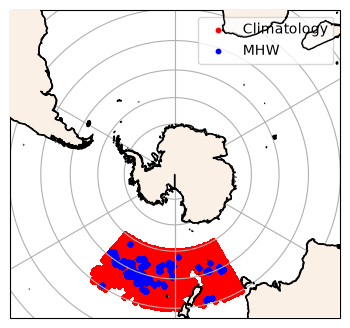

In [23]:
ax = map_study_region(ax_lims = [lon0, lon1, lat0, lat1+10], PROJ = ccrs.SouthPolarStereo())
im = ax.scatter(df_clim['LONGITUDE'], df_clim['LATITUDE'], 
                s = 10, c = 'red',
                transform=ccrs.PlateCarree(), 
                label = "Climatology")
im = ax.scatter(df_mhw['LONGITUDE'], df_mhw['LATITUDE'], 
                s = 10, c = 'blue',
                transform=ccrs.PlateCarree(),
                label = "MHW")
ax.legend()

## 6. Plot MHW with climatology
### 6.1. Average MHW and climatology data across lats and lons

This is to collapse the data to 2 dimensions: time and depth/pressure.

In [24]:
DFMHW = df_mhw.groupby(by = ['JULD', 'PRES']).mean().reset_index()
DFCLIM = df_clim.groupby(by = ['JULD', 'PRES']).mean().reset_index()

### 6.2. Plot by pressure and time
#### 6.2.1. Temperature

NameError: name 'DFCLIM_day' is not defined

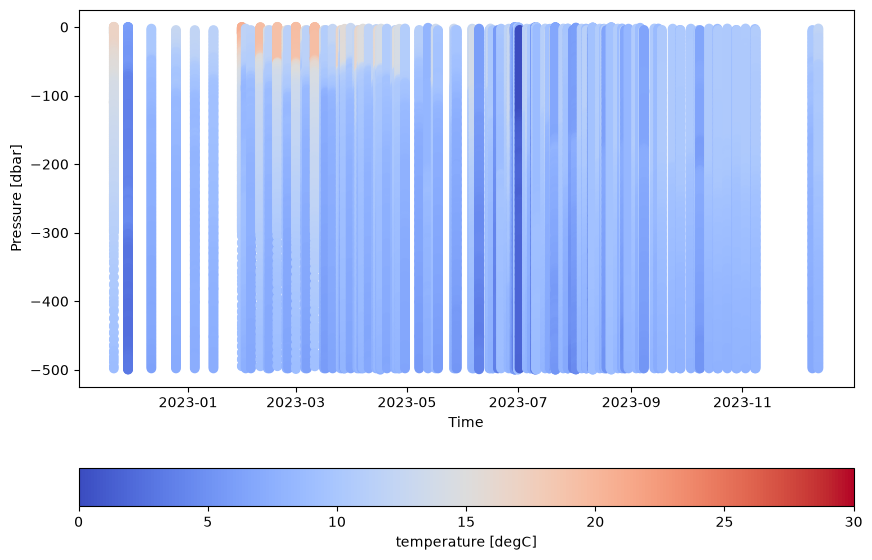

In [25]:
fig, ax = plt.subplots(figsize = [10,7])

x = DFMHW['JULD']
y = -DFMHW['PRES']
z = DFMHW['TEMP']

im = ax.scatter(x, y, c = z, cmap = 'coolwarm', vmin = 0, vmax = 30)
ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")
cbar = plt.colorbar(im, ax = ax, orientation = 'horizontal')
cbar.set_label("temperature [degC]")

x = DFCLIM['JULD']
y = -DFCLIM_day['PRES']
z = DFCLIM_day['TEMP']

im = ax.scatter(x, y, c = z, cmap = 'coolwarm', vmin = 0, vmax = 30)

ax.axvline(date0, color = 'k')
ax.axvline(date1, color = 'k')

### 6.3. Calculate & plot anomalies by day of year

In [26]:
DFMHW = df_mhw.groupby(['JULD', 'PRES']).mean(numeric_only=True).reset_index()
DFCLIM = df_clim.groupby(['JULD', 'PRES']).mean(numeric_only=True).reset_index()

DFMHW['Day'] = DFMHW['JULD'].dt.dayofyear
DFCLIM['Day'] = DFCLIM['JULD'].dt.dayofyear

# Create climatology for each day-of-year and pressure
DFCLIM = (
    DFCLIM
    .groupby(['Day', 'PRES'])
    .mean(numeric_only=True)
    .reset_index()
)

DF = DFMHW.merge(
    DFCLIM,
    on=['Day', 'PRES'],
    suffixes=('_MHW', '_CLIM')
)

variables = [
    col for col in DFMHW.columns
    if col in DFCLIM.columns
    and col not in ['Day', 'PRES', 'JULD']
]

DF_anom = DF[['JULD', 'Day', 'PRES']].copy()

for var in variables:
    DF_anom[var] = DF[f'{var}_MHW'] - DF[f'{var}_CLIM']

#### 6.3.1. Temperature

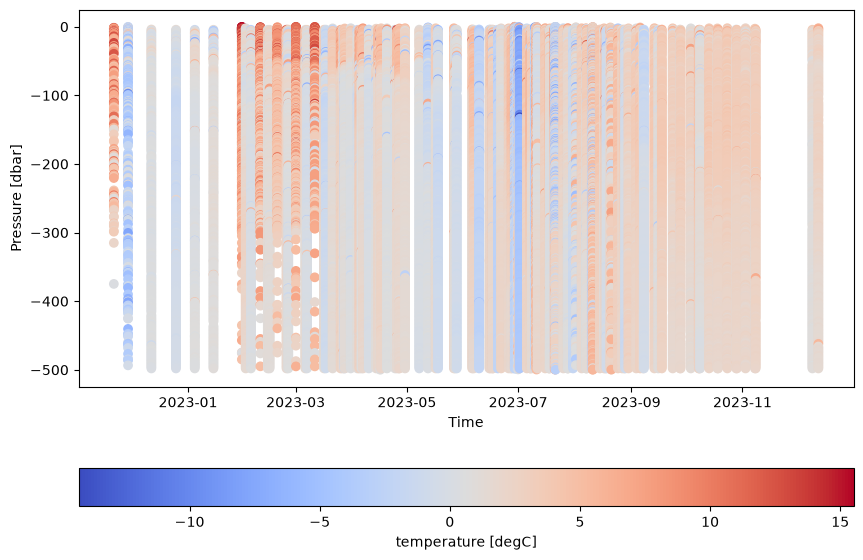

In [27]:
fig, ax = plt.subplots(figsize = [10,7])

x = DF_anom['JULD']
y = -DF_anom['PRES']
z = DF_anom['TEMP']

im = ax.scatter(x, y, c = z, cmap = 'coolwarm')
ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")
cbar = plt.colorbar(im, ax = ax, orientation = 'horizontal')
cbar.set_label("temperature [degC]")

#### 6.3.2. Chla

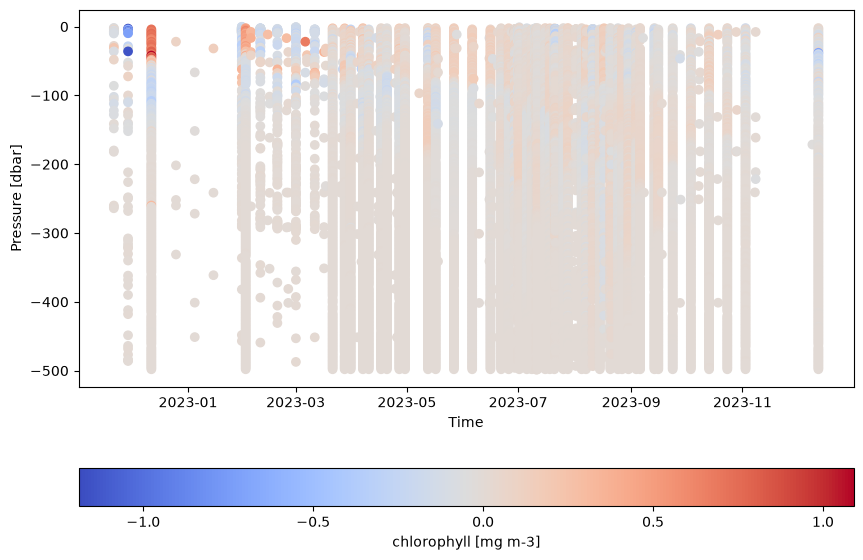

In [28]:
fig, ax = plt.subplots(figsize = [10,7])

x = DF_anom['JULD']
y = -DF_anom['PRES']
z = DF_anom['CHLA_ADJUSTED']

im = ax.scatter(x, y, c = z, cmap = 'coolwarm')
ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")
cbar = plt.colorbar(im, ax = ax, orientation = 'horizontal')
cbar.set_label("chlorophyll [mg m-3]")

### 6.4. Calculate and plot anomalies by week of year

In [29]:
DFMHW = df_mhw.groupby(['JULD', 'PRES']).mean(numeric_only=True).reset_index()
DFCLIM = df_clim.groupby(['JULD', 'PRES']).mean(numeric_only=True).reset_index()

DFMHW['Week'] = DFMHW['JULD'].dt.isocalendar().week
DFCLIM['Week'] = DFCLIM['JULD'].dt.isocalendar().week

# Create climatology for each day-of-year and pressure
DFCLIM = (
    DFCLIM
    .groupby(['Week', 'PRES'])
    .mean(numeric_only=True)
    .reset_index()
)

DF = DFMHW.merge(
    DFCLIM,
    on=['Week', 'PRES'],
    suffixes=('_MHW', '_CLIM')
)

variables = [
    col for col in DFMHW.columns
    if col in DFCLIM.columns
    and col not in ['Week', 'PRES', 'JULD']
]

DF_anom = DF[['JULD', 'Week', 'PRES']].copy()

for var in variables:
    DF_anom[var] = DF[f'{var}_MHW'] - DF[f'{var}_CLIM']

#### 6.4.1. Temperature

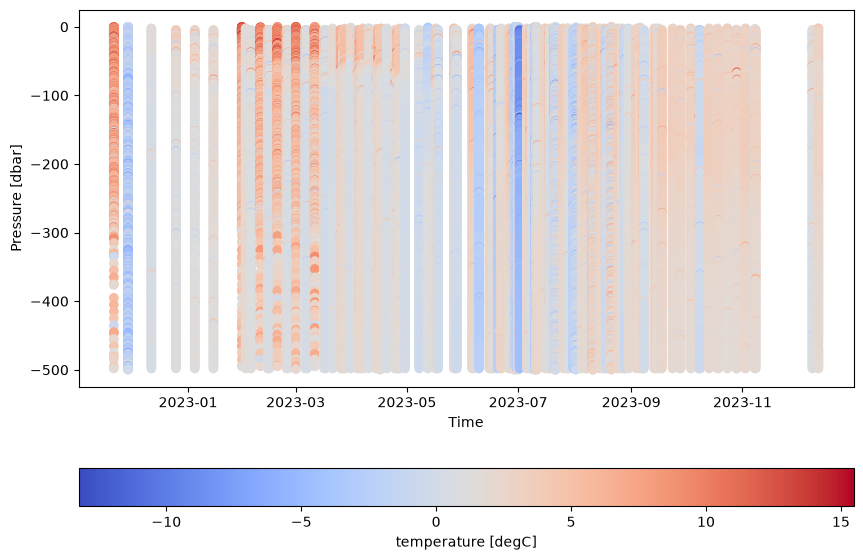

In [30]:
fig, ax = plt.subplots(figsize = [10,7])

x = DF_anom['JULD']
y = -DF_anom['PRES']
z = DF_anom['TEMP']

im = ax.scatter(x, y, c = z, cmap = 'coolwarm')
ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")
cbar = plt.colorbar(im, ax = ax, orientation = 'horizontal')
cbar.set_label("temperature [degC]")

#### 6.4.2. Chla

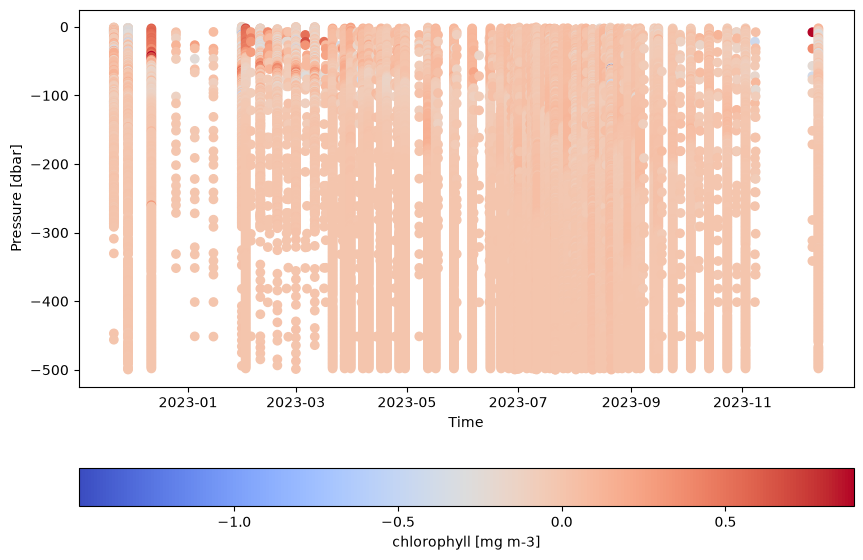

In [31]:
fig, ax = plt.subplots(figsize = [10,7])

x = DF_anom['JULD']
y = -DF_anom['PRES']
z = DF_anom['CHLA_ADJUSTED']

im = ax.scatter(x, y, c = z, cmap = 'coolwarm')
ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")
cbar = plt.colorbar(im, ax = ax, orientation = 'horizontal')
cbar.set_label("chlorophyll [mg m-3]")

#### 6.4.3. Oxygen

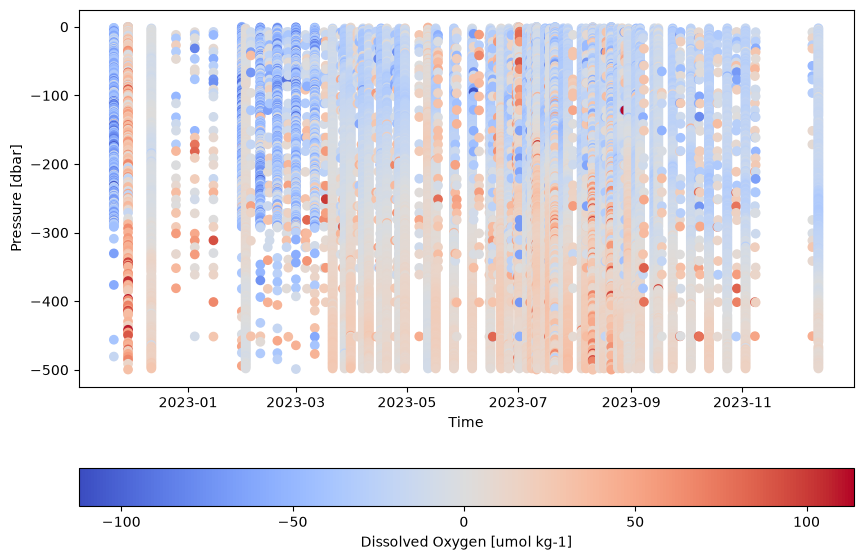

In [32]:
fig, ax = plt.subplots(figsize = [10,7])

x = DF_anom['JULD']
y = -DF_anom['PRES']
z = DF_anom['DOXY_ADJUSTED']

im = ax.scatter(x, y, c = z, cmap = 'coolwarm')
ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")
cbar = plt.colorbar(im, ax = ax, orientation = 'horizontal')
cbar.set_label("Dissolved Oxygen [umol kg-1]")

#### 6.4.4. pH

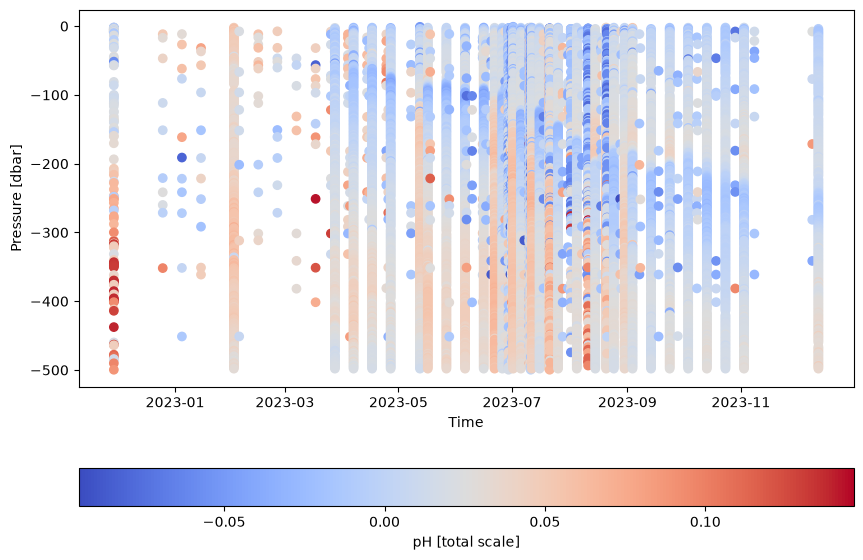

In [33]:
fig, ax = plt.subplots(figsize = [10,7])

x = DF_anom['JULD']
y = -DF_anom['PRES']
z = DF_anom['PH_IN_SITU_TOTAL_ADJUSTED']

im = ax.scatter(x, y, c = z, cmap = 'coolwarm')
ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")
cbar = plt.colorbar(im, ax = ax, orientation = 'horizontal')
cbar.set_label("pH [total scale]")

## 7. Integrate chlorophyll over depth
### 7.1. Map pressure to depth

In [34]:
DFMHW['Depth'] = gsw.z_from_p(DFMHW['PRES'], DFMHW['LATITUDE'])
DFCLIM['Depth'] = gsw.z_from_p(DFCLIM['PRES'], DFCLIM['LATITUDE'])

### 7.2. Integrate over depth using [`np.trapezoid(y)`](https://numpy.org/devdocs/reference/generated/numpy.trapezoid.html)

In [35]:
def integrate_over_depth(group, variable='CHLA_ADJUSTED', max_depth=200):
    g = group[['Depth', variable]].dropna().copy()

    # Keep upper 200 m: -200 m to 0 m
    g = g[(g['Depth'] >= -max_depth) & (g['Depth'] <= 0)]

    if len(g) < 2:
        return np.nan

    # Convert to positive depth: 0 at surface, increasing downward
    g['Depth_positive'] = -g['Depth']

    # Sort surface to deep
    g = g.sort_values('Depth_positive')

    return np.trapezoid(
        g[variable].values,
        x=g['Depth_positive'].values
    )


DFMHW_integrated = (
    DFMHW
    .groupby(['JULD', 'PLATFORM_NUMBER', 'N_PROF'])
    .apply(integrate_over_depth, variable='CHLA_ADJUSTED')
    .reset_index(name='CHLA_integrated')
)

DFCLIM_integrated = (
    DFCLIM
    .groupby(['Week', 'PLATFORM_NUMBER', 'N_PROF'])
    .apply(integrate_over_depth, variable='CHLA_ADJUSTED')
    .reset_index(name='CHLA_integrated')
)

### 7.3. Get anomalies of integrated chlorophyll by week

In [36]:
DFMHW_integrated['Week'] = DFMHW_integrated['JULD'].dt.isocalendar().week

DF = DFMHW_integrated.merge(
    DFCLIM_integrated.groupby(by = ['Week']).mean().reset_index(),
    on=['Week'],
    suffixes=('_MHW', '_CLIM')
)

variables = [
    col for col in DFMHW_integrated.columns
    if col in DFMHW_integrated.columns
    and col not in ['Week', 'JULD']
]

DF_anom_int = DF[['JULD', 'Week']].copy()

for var in variables:
    DF_anom_int[var] = DF[f'{var}_MHW'] - DF[f'{var}_CLIM']

### 7.4. Plot depth integrated chlorophyll

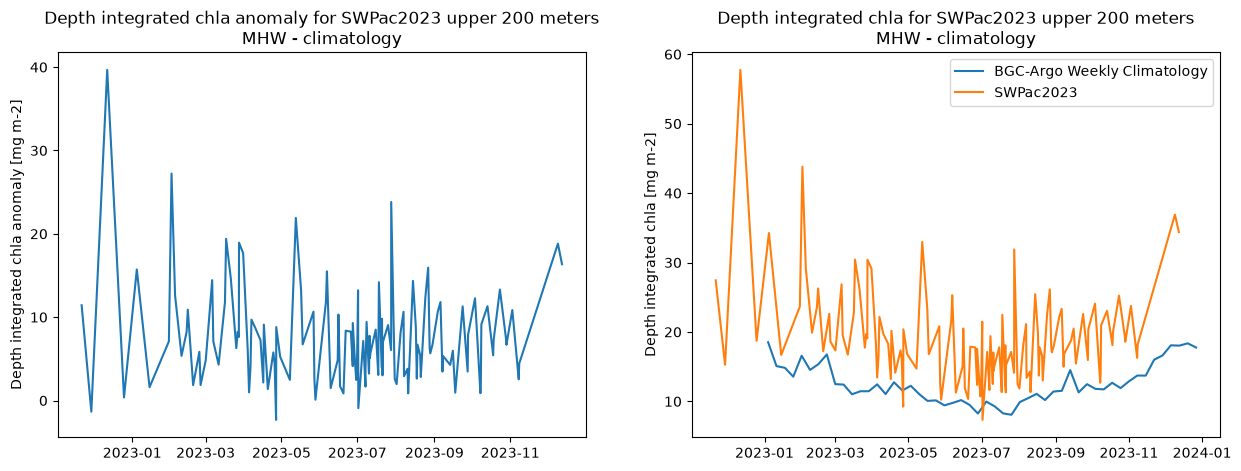

In [37]:
fig, axarr = plt.subplots(ncols = 2, figsize = [15,5])
axarr = axarr.flatten()

ax = axarr[0]
x = DF_anom_int['JULD']
y = DF_anom_int['CHLA_integrated']
ax.plot(x,y)
ax.set_ylabel("Depth integrated chla anomaly [mg m-2]")
ax.set_title(f"Depth integrated chla anomaly for {hw} upper 200 meters\nMHW - climatology")

ax = axarr[1]
dates = [datetime.date.fromisocalendar(2023, int(week), 3)
         for week in (DFCLIM_integrated.groupby('Week').mean(numeric_only=True).reset_index()['Week']) 
         if week != 53
        ]
y = DFCLIM_integrated.groupby('Week').mean(numeric_only=True).reset_index()
y = y['CHLA_integrated'][y['Week'] < 53]
ax.plot(dates,y, label = "BGC-Argo Weekly Climatology")

x = DFMHW_integrated['JULD']
y = DFMHW_integrated['CHLA_integrated']
ax.plot(x,y, label = f"{hw}")
ax.set_ylabel("Depth integrated chla [mg m-2]")
ax.set_title(f"Depth integrated chla for {hw} upper 200 meters\nMHW - climatology")
ax.legend()

### 7.5. Get standard deviation for weekly climatology

In [38]:
# get depth from pressure
df_clim['Depth'] = gsw.z_from_p(df_clim['PRES'], df_clim['LATITUDE'])

# integrated each climatological profile
DF_profile = (
    df_clim
    .groupby(['JULD', 'PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    .apply(
        integrate_over_depth,
        variable='CHLA_ADJUSTED'
    )
    .reset_index(name='CHLA_integrated')
)

# get day of the year
DF_profile['Day'] = DF_profile['JULD'].dt.floor('D')

# calculate daily stats
DF_daily = (
    DF_profile
    .groupby('Day')
    .agg(
        CHLA_integrated_mean=('CHLA_integrated', 'mean'),
        CHLA_integrated_sd=('CHLA_integrated', 'std'),
        n_profiles=('CHLA_integrated', 'count')
    )
    .reset_index()
)
DF_daily['CHLA_integrated_se'] = (
    DF_daily['CHLA_integrated_sd'] /
    np.sqrt(DF_daily['n_profiles'])
)

# assign week
DF_daily['Week'] = (
    DF_daily['Day']
    .dt.isocalendar()
    .week
    .astype(int)
)

# weekly stats
DF_weekly = (
    DF_daily
    .groupby('Week')
    .agg(
        CHLA_integrated_mean=('CHLA_integrated_mean', 'mean'),
        CHLA_integrated_sd=('CHLA_integrated_mean', 'std'),
        n_days=('CHLA_integrated_mean', 'count'),
        n_profiles=('n_profiles', 'sum')
    )
    .reset_index()
)
DF_weekly['CHLA_integrated_se'] = (
    DF_weekly['CHLA_integrated_sd'] /
    np.sqrt(DF_weekly['n_days'])
)

#### 7.5.1. Plot with standard error

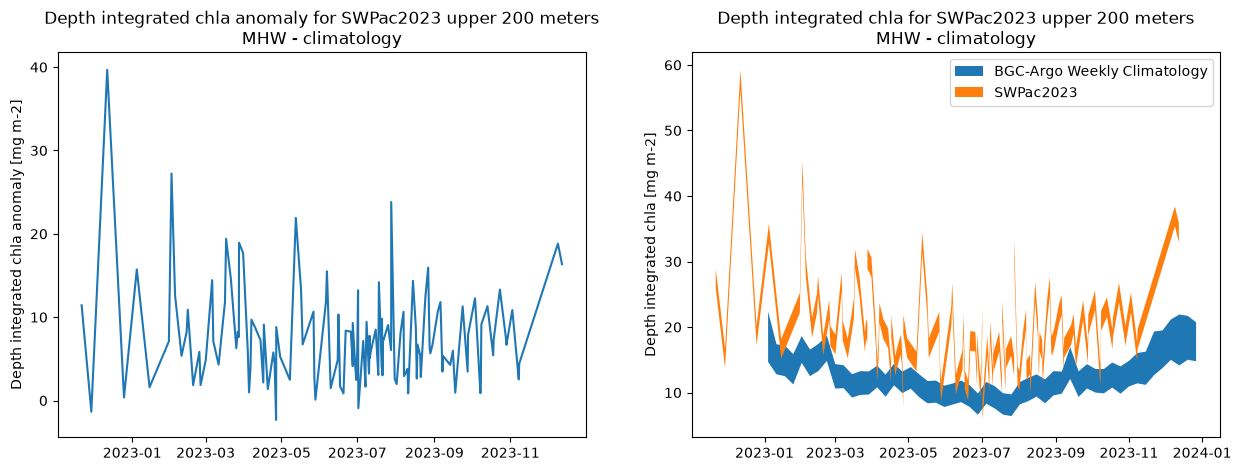

In [39]:
fig, axarr = plt.subplots(ncols = 2, figsize = [15,5])
axarr = axarr.flatten()

ax = axarr[0]
x = DF_anom_int['JULD']
y = DF_anom_int['CHLA_integrated']
ax.plot(x,y)
ax.set_ylabel("Depth integrated chla anomaly [mg m-2]")
ax.set_title(f"Depth integrated chla anomaly for {hw} upper 200 meters\nMHW - climatology")

ax = axarr[1]
dates = [datetime.date.fromisocalendar(2023, int(week), 3)
         for week in (DFCLIM_integrated.groupby('Week').mean(numeric_only=True).reset_index()['Week']) 
         if week != 53
        ]
y = DFCLIM_integrated.groupby('Week').mean(numeric_only=True).reset_index()
y = y['CHLA_integrated'][y['Week'] < 53]
yerr = np.sqrt(DF_weekly['CHLA_integrated_se'][DF_weekly['Week']<53]**2 + 1.5**2)
ax.fill_between(dates,y + yerr, y - yerr, label = "BGC-Argo Weekly Climatology")

x = DFMHW_integrated['JULD']
y = DFMHW_integrated['CHLA_integrated']
yerr = 1.5
ax.fill_between(x,y - yerr, y + yerr, label = f"{hw}")
ax.set_ylabel("Depth integrated chla [mg m-2]")
ax.set_title(f"Depth integrated chla for {hw} upper 200 meters\nMHW - climatology")
ax.legend()

## 8. Mixed layer depth
### 8.1. Calculate conservative temperature, absolute salinity, and potential density 
This is done on the datasets that have not been averaged across location for each time.

In [47]:

df_mhw['ASAL'] = gsw.SA_from_SP(df_mhw['PSAL'], df_mhw['PRES'], df_mhw['LONGITUDE'], df_mhw['LATITUDE'])
df_mhw['CTEMP'] = gsw.CT_from_t(df_mhw['ASAL'], df_mhw['TEMP'], df_mhw['PRES'])
df_mhw['sigma0'] = gsw.sigma0(df_mhw['ASAL'], df_mhw['CTEMP'])

df_clim['ASAL'] = gsw.SA_from_SP(df_clim['PSAL'], df_clim['PRES'], df_clim['LONGITUDE'], df_clim['LATITUDE'])
df_clim['CTEMP'] = gsw.CT_from_t(df_clim['ASAL'], df_clim['TEMP'], df_clim['PRES'])
df_clim['sigma0'] = gsw.sigma0(df_clim['ASAL'], df_clim['CTEMP'])

/opt/conda/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in ct_from_t
  result = getattr(ufunc, method)(*inputs, **kwargs)


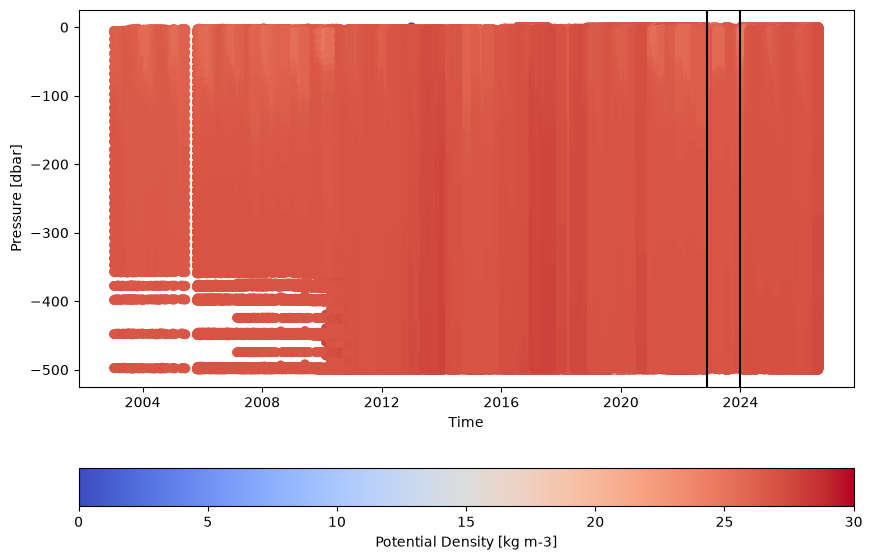

In [51]:
fig, ax = plt.subplots(figsize = [10,7])

x = df_mhw['JULD']
y = -df_mhw['PRES']
z = df_mhw['sigma0']

im = ax.scatter(x, y, c = z, cmap = 'coolwarm', vmin = 0, vmax = 30)
ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")
cbar = plt.colorbar(im, ax = ax, orientation = 'horizontal')
cbar.set_label("Potential Density [kg m-3]")

x = df_clim['JULD']
y = -df_clim['PRES']
z = df_clim['sigma0']

im = ax.scatter(x, y, c = z, cmap = 'coolwarm')

ax.axvline(date0, color = 'k')
ax.axvline(date1, color = 'k')

### 8.2. Overwrite the spatially averaged datasets (`DFMHW` and `DFCLIM`), averaging the same way but now with potential denisty

In [260]:
DFMHW = df_mhw.groupby(by = ['JULD', 'PRES']).mean().reset_index()
DFCLIM = df_clim.groupby(by = ['JULD', 'PRES']).mean().reset_index()

### 8.3. Add in depth from pressure again

In [261]:
DFMHW['Depth'] = gsw.z_from_p(DFMHW['PRES'], DFMHW['LATITUDE'])
DFCLIM['Depth'] = gsw.z_from_p(DFCLIM['PRES'], DFCLIM['LATITUDE'])

### 8.4. Define MLD
where potential density is greater than surface potential density by 0.03 kg m<sup>-3</sup>

[Hosoda, S., Ohira, T., Sato, K., & Suga, T. (2010). Improved description of global mixed-layer depth using Argo profiling floats. Journal of oceanography, 66(6), 773-787.](https://link.springer.com/article/10.1007/s10872-010-0063-3)

#### 8.4.1. MHW

In [140]:
temp = {"JULD": [], "MLD": []}

for t, time in enumerate(DFMHW['JULD'].unique()):
    sample = DFMHW[DFMHW['JULD']== time].reset_index()
    z = sample['Depth']
    sigma = sample['sigma0']
    dsigma = 0.03
    target = sigma[0] + dsigma
    if target <= sigma.max():
        idx = np.where(sigma >= target)[0][0]
        MLD = z[idx]
    else:
        MLD = z.min()

    temp["JULD"].append(time)
    temp["MLD"].append(-MLD)

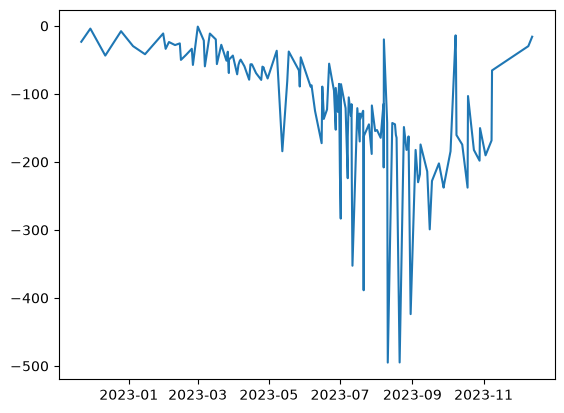

In [141]:
MLD_mhw = pd.DataFrame(temp)
plt.plot(MLD_mhw["JULD"], -MLD_mhw["MLD"])

In [268]:
match_to_week = True
if match_to_week:
    DFMHW['week'] = DFMHW['JULD'].dt.isocalendar().week
    MLD_clim_weekly = MLD_clim.groupby(MLD_clim['JULD'].dt.isocalendar().week).mean(numeric_only=True).reset_index()
    
    DFMHW = DFMHW.merge(
        MLD_clim_weekly[['week', 'MLD']],
        on='week',
        how='left'
    )
else:
    DFMHW = DFMHW.merge(
        MLD_mhw[['JULD', 'MLD']],
        on='JULD',
        how='left'
    )

#### 8.4.2. Climatology

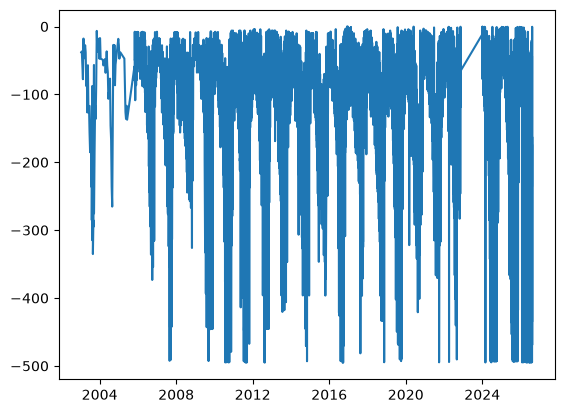

In [143]:
temp = {"JULD": [], "MLD": []}

for t, time in enumerate(DFCLIM['JULD'].unique()):
    sample = DFCLIM[DFCLIM['JULD']== time].reset_index()
    z = sample['Depth']
    sigma = sample['sigma0']
    dsigma = 0.03
    target = sigma[0] + dsigma
    if target <= sigma.max():
        idx = np.where(sigma >= target)[0][0]
        MLD = z[idx]
    else:
        MLD = z.min()

    temp["JULD"].append(time)
    temp["MLD"].append(-MLD)

MLD_clim = pd.DataFrame(temp)
plt.plot(MLD_clim["JULD"], -MLD_clim["MLD"])

DFCLIM = DFCLIM.merge(
    MLD_clim[['JULD', 'MLD']],
    on='JULD',
    how='left'
)

#### 8.4.2. Plot MLDs

Text(0.5, 1.0, 'Southwest Pacific: -50.0degS 5.0degW')

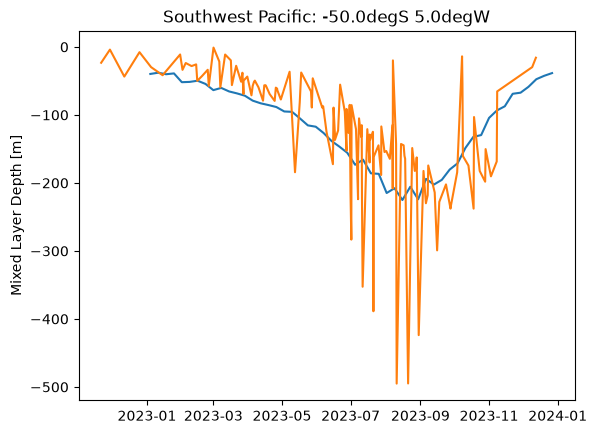

In [259]:
fig, ax = plt.subplots()

MLD_clim_weekly = MLD_clim.groupby(MLD_clim['JULD'].dt.isocalendar().week).mean(numeric_only=True).reset_index()
MLD_clim_weekly = MLD_clim_weekly[MLD_clim_weekly["week"] < 53]
dates = [datetime.date.fromisocalendar(2023, int(week), 3)
         for week in (MLD_clim_weekly['week']) 
         if week != 53
        ]
mld = MLD_clim_weekly["MLD"]

ax.plot(dates, -mld, label = 'Float Climatology')
ax.plot(MLD_mhw["JULD"], -MLD_mhw["MLD"], label = 'South Pacific 2023 Heat Wave Float')
ax.set_ylabel("Mixed Layer Depth [m]")
ax.set_title(f"Southwest Pacific: {np.mean([lat0,lat1])}degS {np.mean([lon0,lon1])}degW")

### 8.5. Integrate from 0 to MLD

#### 8.5.1. Function to integrate over variable depths

In [231]:
def integrate_over_variable_depth(
    group,
    variable='CHLA_ADJUSTED',
    min_depth=0,
    max_depth=200
):
    """
    Integrate over the available portion of the requested depth interval.

    min_depth and max_depth can each be:
      - numeric constants, e.g. 0, 20, 200
      - column names, e.g. 'MLD'

    The requested interval is clipped to the range where valid data exist.

    Assumes:
      - dataframe Depth is negative downward
      - depth limits are interpreted as positive-down meters
    """

    # --------------------------------
    # Requested minimum depth
    # --------------------------------
    if isinstance(min_depth, str):
        requested_zmin = group[min_depth].iloc[0]
    else:
        requested_zmin = min_depth

    # --------------------------------
    # Requested maximum depth
    # --------------------------------
    if isinstance(max_depth, str):
        requested_zmax = group[max_depth].iloc[0]
    else:
        requested_zmax = max_depth

    if pd.isna(requested_zmin) or pd.isna(requested_zmax):
        return np.nan

    requested_zmin = abs(float(requested_zmin))
    requested_zmax = abs(float(requested_zmax))

    # Ensure shallow -> deep ordering
    if requested_zmin > requested_zmax:
        requested_zmin, requested_zmax = (
            requested_zmax,
            requested_zmin
        )

    # --------------------------------
    # Valid profile observations
    # --------------------------------
    g = group[['Depth', variable]].dropna().copy()

    if len(g) < 2:
        return np.nan

    # Convert negative-down to positive-down
    g['Depth_positive'] = -g['Depth']

    # Remove values above sea level
    g = g[g['Depth_positive'] >= 0]

    # Average duplicate depths and sort
    g = (
        g[['Depth_positive', variable]]
        .groupby('Depth_positive', as_index=False)
        .mean()
        .sort_values('Depth_positive')
    )

    if len(g) < 2:
        return np.nan

    # --------------------------------
    # Available depth range
    # --------------------------------
    shallowest_available = g['Depth_positive'].min()
    deepest_available = g['Depth_positive'].max()

    # Clip requested integration interval
    # to actual available data
    zmin = max(
        requested_zmin,
        shallowest_available
    )

    zmax = min(
        requested_zmax,
        deepest_available
    )

    # No overlap between requested interval and data
    if zmax <= zmin:
        return np.nan

    # --------------------------------
    # Interpolate at exact boundaries
    # --------------------------------
    value_min = np.interp(
        zmin,
        g['Depth_positive'].values,
        g[variable].values
    )

    value_max = np.interp(
        zmax,
        g['Depth_positive'].values,
        g[variable].values
    )

    # Observations inside interval
    g_int = g[
        (g['Depth_positive'] > zmin) &
        (g['Depth_positive'] < zmax)
    ].copy()

    # Add exact boundaries
    boundaries = pd.DataFrame({
        'Depth_positive': [zmin, zmax],
        variable: [value_min, value_max]
    })

    g_int = (
        pd.concat(
            [boundaries, g_int],
            ignore_index=True
        )
        .sort_values('Depth_positive')
    )

    if len(g_int) < 2:
        return np.nan

    return np.trapezoid(
        g_int[variable].values,
        x=g_int['Depth_positive'].values
    )

#### 8.4.3. MHW MLD Integration

In [270]:
DFMHW_integrated_MLD = (
    DFMHW
    .groupby(['JULD', 'PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    .apply(
        integrate_over_variable_depth,
        variable='CHLA_ADJUSTED',
        min_depth=0,
        max_depth='MLD')
    .reset_index(name='CHLA_integrated')
)

#### 8.4.4. Climatology MLD Integration

In [234]:

# integrated each climatological profile
DF_profile_clim = (
    DFCLIM
    .groupby(['JULD', 'PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    .apply(
        integrate_over_variable_depth,
        variable='CHLA_ADJUSTED',
        min_depth=0,
        max_depth='MLD')
    .reset_index(name='CHLA_integrated')
)

# get day of the year
DF_profile_clim['Day'] = DF_profile_clim['JULD'].dt.floor('D')

# calculate daily stats
DF_daily_clim = (
    DF_profile_clim
    .groupby('Day')
    .agg(
        CHLA_integrated_mean=('CHLA_integrated', 'mean'),
        CHLA_integrated_sd=('CHLA_integrated', 'std'),
        n_profiles=('CHLA_integrated', 'count')
    )
    .reset_index()
)
DF_daily_clim['CHLA_integrated_se'] = (
    DF_daily_clim['CHLA_integrated_sd'] /
    np.sqrt(DF_daily_clim['n_profiles'])
)

# assign week
DF_daily_clim['Week'] = (
    DF_daily_clim['Day']
    .dt.isocalendar()
    .week
    .astype(int)
)

# weekly stats
DF_weekly_clim = (
    DF_daily_clim
    .groupby('Week')
    .agg(
        CHLA_integrated_mean=('CHLA_integrated_mean', 'mean'),
        CHLA_integrated_sd=('CHLA_integrated_mean', 'std'),
        n_days=('CHLA_integrated_mean', 'count'),
        n_profiles=('n_profiles', 'sum')
    )
    .reset_index()
)
DF_weekly_clim['CHLA_integrated_se'] = (
    DF_weekly['CHLA_integrated_sd'] /
    np.sqrt(DF_weekly['n_days'])
)

DFCLIM_integrated_MLD = DF_weekly_clim.copy()
del DF_profile_clim, DF_daily_clim, DF_weekly_clim

### 8.6. Integrate from MLD to bottom of 500m profile

#### 8.6.1. MHW sub-MLD integrated Chla

In [271]:
DFMHW_integrated_subMLD = (
    DFMHW
    .groupby(['JULD', 'PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    .apply(
        integrate_over_variable_depth,
        variable='CHLA_ADJUSTED',
        min_depth='MLD',
        max_depth=500)
    .reset_index(name='CHLA_integrated')
)

#### 8.6.2. Climatology sub-MLD integrated Chla

In [236]:

# integrated each climatological profile
DF_profile_clim = (
    DFCLIM
    .groupby(['JULD', 'PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    .apply(
        integrate_over_variable_depth,
        variable='CHLA_ADJUSTED',
        min_depth='MLD',
        max_depth=500)
    .reset_index(name='CHLA_integrated')
)

# get day of the year
DF_profile_clim['Day'] = DF_profile_clim['JULD'].dt.floor('D')

# calculate daily stats
DF_daily_clim = (
    DF_profile_clim
    .groupby('Day')
    .agg(
        CHLA_integrated_mean=(
            'CHLA_integrated',
            lambda x: np.nanmean(x)
        ),
        CHLA_integrated_sd=(
            'CHLA_integrated',
            lambda x: np.nanstd(x)
        ),
        n_profiles_valid=(
            'CHLA_integrated',
            lambda x: x.notna().sum()
        ),
        n_profiles_total=(
            'CHLA_integrated',
            'size'
        )
    )
    .reset_index()
)
DF_daily_clim['CHLA_integrated_se'] = (
    DF_daily_clim['CHLA_integrated_sd'] /
    np.sqrt(DF_daily_clim['n_profiles_valid'])
)

# assign week
DF_daily_clim['Week'] = (
    DF_daily_clim['Day']
    .dt.isocalendar()
    .week
    .astype(int)
)

# weekly stats
DF_weekly_clim = (
    DF_daily_clim
    .groupby('Week')
    .agg(
        CHLA_integrated_mean=('CHLA_integrated_mean', 'mean'),
        CHLA_integrated_sd=('CHLA_integrated_mean', 'std'),
        n_days=('CHLA_integrated_mean', 'count'),
        n_profiles=('n_profiles_valid', 'sum')
    )
    .reset_index()
)
DF_weekly_clim['CHLA_integrated_se'] = (
    DF_weekly_clim['CHLA_integrated_sd'] /
    np.sqrt(DF_weekly['n_days'])
)

DFCLIM_integrated_subMLD = DF_weekly_clim.copy()
del DF_profile_clim, DF_daily_clim, DF_weekly_clim

/tmp/ipykernel_182/3852413471.py:23: RuntimeWarning: Mean of empty slice
  lambda x: np.nanmean(x)


/opt/conda/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


### 8.7. Get integrated MLD/sub-MLD anomalies

#### 8.7.1. Function to get anomalies

In [212]:
def get_integrated_anomalies_weekly(mhw_float_data, climatology_float_data):

    mhw_float_data['Week'] = mhw_float_data['JULD'].dt.isocalendar().week

    if 'CHLA_integrated_mean' in climatology_float_data.columns:
        climatology_float_data = climatology_float_data.rename(columns={'CHLA_integrated_mean': 'CHLA_integrated'})

    DF = mhw_float_data.merge(
        climatology_float_data.groupby(by = ['Week']).mean().reset_index(),
        on=['Week'],
        suffixes=('_MHW', '_CLIM')
    )
    
    variables = [
        col for col in mhw_float_data.columns
        if col in mhw_float_data.columns
        and col not in ['Week', 'JULD', 'PLATFORM_NUMBER', 'CYCLE_NUMBER']
    ]
    
    DF_anom_int = DF[['JULD', 'Week']].copy()
    
    for var in variables:
        DF_anom_int[var] = DF[f'{var}_MHW'] - DF[f'{var}_CLIM']
    return DF_anom_int

#### 8.7.2. Get the anomalies

In [272]:
DF_anom_MLD = get_integrated_anomalies_weekly(DFMHW_integrated_MLD, DFCLIM_integrated_MLD)
DF_anom_subMLD = get_integrated_anomalies_weekly(DFMHW_integrated_subMLD, DFCLIM_integrated_subMLD)

#### 8.7.3. Plot the anomalies

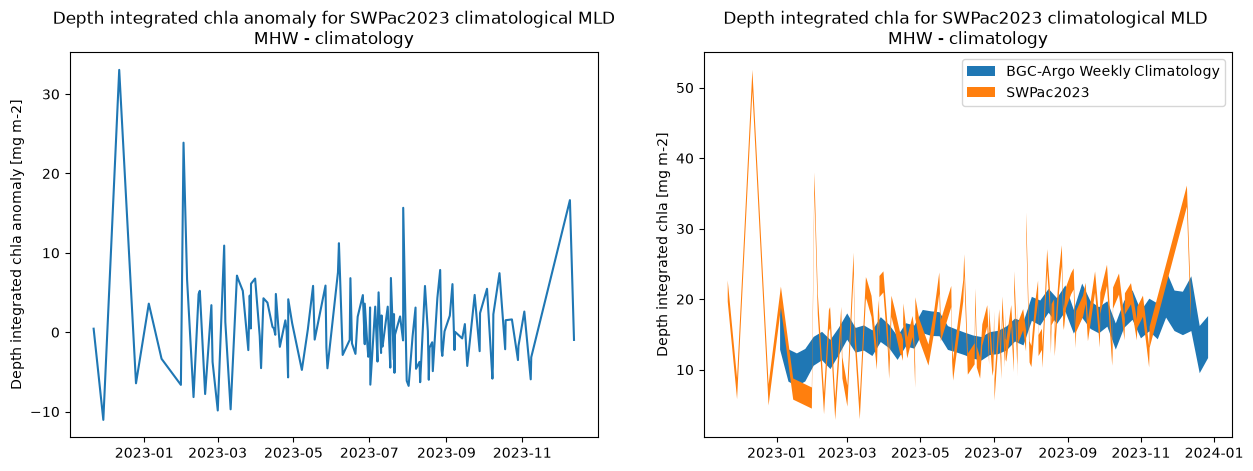

In [275]:
fig, axarr = plt.subplots(ncols = 2, figsize = [15,5])
axarr = axarr.flatten()

ax = axarr[0]
x = DF_anom_MLD['JULD']
y = DF_anom_MLD['CHLA_integrated']
ax.plot(x,y)
ax.set_ylabel("Depth integrated chla anomaly [mg m-2]")
ax.set_title(f"Depth integrated chla anomaly for {hw} climatological MLD\nMHW - climatology")

ax = axarr[1]
dates = [datetime.date.fromisocalendar(2023, int(week), 3)
         for week in (DFCLIM_integrated_MLD.groupby('Week').mean(numeric_only=True).reset_index()['Week']) 
         if week != 53
        ]
y = DFCLIM_integrated_MLD.groupby('Week').mean(numeric_only=True).reset_index()
if 'CHLA_integrated' in y.columns:
    var = 'CHLA_integrated'
elif 'CHLA_integrated_mean' in y.columns:
    var = 'CHLA_integrated_mean'
y = y[var][y['Week'] < 53]
yerr = np.sqrt(DF_weekly['CHLA_integrated_se'][DF_weekly['Week']<53]**2 + 1.5**2)
ax.fill_between(dates,y + yerr, y - yerr, label = "BGC-Argo Weekly Climatology")

x = DFMHW_integrated_MLD['JULD']
y = DFMHW_integrated_MLD['CHLA_integrated']
yerr = 1.5
ax.fill_between(x,y - yerr, y + yerr, label = f"{hw}")
ax.set_ylabel("Depth integrated chla [mg m-2]")
ax.set_title(f"Depth integrated chla for {hw} climatological MLD \nMHW - climatology")
ax.legend()

In [276]:
DFMHW.keys()

Index(['JULD', 'PRES', 'PLATFORM_NUMBER', 'N_PROF', 'N_LEVELS', 'CYCLE_NUMBER',
       'LATITUDE', 'LONGITUDE', 'TEMP', 'PSAL', 'DOXY_ADJUSTED',
       'DOXY_ADJUSTED_QC', 'DOXY_ADJUSTED_ERROR', 'BBP_ADJUSTED',
       'BBP_ADJUSTED_QC', 'BBP_ADJUSTED_ERROR', 'TURBIDITY_ADJUSTED',
       'TURBIDITY_ADJUSTED_QC', 'TURBIDITY_ADJUSTED_ERROR', 'CP_ADJUSTED',
       'CP_ADJUSTED_QC', 'CP_ADJUSTED_ERROR', 'CHLA_ADJUSTED',
       'CHLA_ADJUSTED_QC', 'CHLA_ADJUSTED_ERROR', 'CHLA_FLUORESCENCE_ADJUSTED',
       'CHLA_FLUORESCENCE_ADJUSTED_QC', 'CHLA_FLUORESCENCE_ADJUSTED_ERROR',
       'CDOM_ADJUSTED', 'CDOM_ADJUSTED_QC', 'CDOM_ADJUSTED_ERROR',
       'NITRATE_ADJUSTED', 'NITRATE_ADJUSTED_QC', 'NITRATE_ADJUSTED_ERROR',
       'BISULFIDE_ADJUSTED', 'BISULFIDE_ADJUSTED_QC',
       'BISULFIDE_ADJUSTED_ERROR', 'PH_IN_SITU_TOTAL_ADJUSTED',
       'PH_IN_SITU_TOTAL_ADJUSTED_QC', 'PH_IN_SITU_TOTAL_ADJUSTED_ERROR',
       'DOWN_IRRADIANCE_ADJUSTED', 'DOWN_IRRADIANCE_ADJUSTED_QC',
       'DOWN_IRRADIANCE_